In [ ]:
!pip install av

In [ ]:
import torch
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torchvision.io import read_video
from PIL import Image
from torchvision import transforms

model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base", num_labels=28)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import os
from sklearn.model_selection import train_test_split

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, processor, num_frames=16, transforms=None):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames
        self.transforms = transforms

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        video, _, _ = read_video(video_path, pts_unit='sec')
        step = max(1, video.shape[0] // self.num_frames)
        frames = [frame.numpy() for frame in video[::step][:self.num_frames]]

        pil_frames = [Image.fromarray(frame.astype(np.uint8)) for frame in frames]

        if self.transforms:
            pil_frames = [self.transforms(frame) for frame in pil_frames]

        inputs = self.processor(images=pil_frames, return_tensors="pt")

        inputs['labels'] = torch.tensor(label, dtype=torch.long)

        return inputs


def get_video_paths_and_labels(root_dir):
    video_paths = []
    labels = []

    for label, class_folder in enumerate(sorted(os.listdir(root_dir))):
        class_path = os.path.join(root_dir, class_folder)

        if os.path.isdir(class_path):
            for video_file in sorted(os.listdir(class_path)):
                video_path = os.path.join(class_path, video_file)
                if video_path.endswith(('.mp4', '.avi', '.mov')):
                    video_paths.append(video_path)
                    labels.append(label)

    return video_paths, labels

root_dir = "/content/drive/MyDrive/Colab Notebooks/data"
video_paths, labels = get_video_paths_and_labels(root_dir)

train_video_paths, test_video_paths, train_labels, test_labels = train_test_split(video_paths, labels, test_size=0.2, random_state=101)

train_dataset = VideoDataset(train_video_paths, train_labels, processor, num_frames=16)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

test_dataset = VideoDataset(test_video_paths, test_labels, processor, num_frames=16)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

In [ ]:
print(f"Labels range min={min(labels)}, max={max(labels)}")

Labels range min=0, max=27


In [ ]:
import numpy as np
import torch
import time

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


epochs = 20
for epoch in range(epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in train_loader:
        inputs = {key: value.squeeze().to(device) for key, value in batch.items()}
        labels = inputs.pop('labels')

        optimizer.zero_grad()

        outputs = model(**inputs)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    average_loss = running_loss / len(train_loader)
    end_time = time.time()
    total_time = (end_time - start_time) / 60
    print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.2f}%, , Loss: {average_loss:.4f}, Total Time: {total_time:.4f}")

Epoch 1/20, Accuracy: 2.16%, , Loss: 3.4261, Total Time: 10.9082
Epoch 2/20, Accuracy: 3.03%, , Loss: 3.3573, Total Time: 10.4424
Epoch 3/20, Accuracy: 4.47%, , Loss: 3.3099, Total Time: 10.3327
Epoch 4/20, Accuracy: 5.33%, , Loss: 3.2466, Total Time: 10.3448
Epoch 5/20, Accuracy: 7.64%, , Loss: 3.1231, Total Time: 10.3336
Epoch 6/20, Accuracy: 12.54%, , Loss: 2.9673, Total Time: 10.3201
Epoch 7/20, Accuracy: 15.99%, , Loss: 2.7488, Total Time: 10.6212
Epoch 8/20, Accuracy: 21.76%, , Loss: 2.4990, Total Time: 10.3187
Epoch 9/20, Accuracy: 27.38%, , Loss: 2.2755, Total Time: 10.2994
Epoch 10/20, Accuracy: 36.74%, , Loss: 1.9517, Total Time: 10.3234
Epoch 11/20, Accuracy: 46.54%, , Loss: 1.6662, Total Time: 10.3002
Epoch 12/20, Accuracy: 56.63%, , Loss: 1.3393, Total Time: 10.3276
Epoch 13/20, Accuracy: 71.61%, , Loss: 0.9491, Total Time: 10.3300
Epoch 14/20, Accuracy: 79.11%, , Loss: 0.6918, Total Time: 10.3354
Epoch 15/20, Accuracy: 85.88%, , Loss: 0.4612, Total Time: 10.3261
Epoch 16/

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
correct = 0
total = 0
running_loss = 0.0
criterion = torch.nn.CrossEntropyLoss()

y_true = []
y_pred = []

with torch.no_grad():
    start_time = time.time()

    for batch in test_loader:
        inputs = {key: value.squeeze().to(device) for key, value in batch.items()}
        labels = inputs.pop('labels')

        outputs = model(**inputs)
        logits = outputs.logits

        loss = criterion(logits, labels)
        running_loss += loss.item()

        _, predicted = torch.max(logits, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    end_time = time.time()
    total_time = (end_time - start_time) / 60

    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Average Loss: {running_loss / len(test_loader):.4f}")
    print(f"Total Time for Testing: {total_time:.2f} minutes")

Test Accuracy: 12.07%
Average Loss: 4.6866
Total Time for Testing: 1.76 minutes


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         4
           3       0.12      0.12      0.12         8
           4       0.11      0.10      0.11        10
           5       0.20      0.12      0.15         8
           6       0.12      0.25      0.17         8
           7       0.00      0.00      0.00         6
           8       0.14      0.25      0.18         4
           9       0.00      0.00      0.00         8
          10       0.40      0.22      0.29         9
          11       0.10      0.17      0.12         6
          12       0.00      0.00      0.00         5
          13       0.10      0.20      0.13         5
          14       0.50      0.11      0.18         9
          15       0.00      0.00      0.00         4
          16       0.00      0.00      0.00         5
   

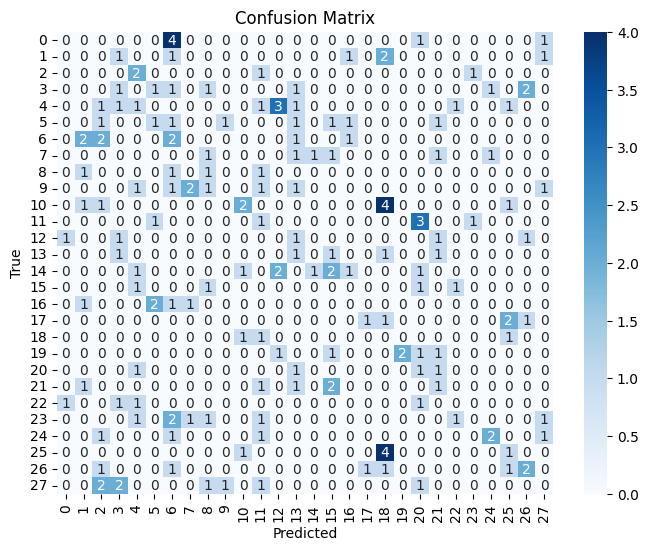

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [10]:
from google.colab import files

torch.save(model.state_dict(), "Epoch_20.pth")
files.download("Epoch_20.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>